In [2]:
import numpy as np
import pandas as pd

import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df=pd.read_csv("Customer_Analytics_Dataset.csv")
df

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TenureYears,Gender,CustomerSegment
0,1,62,657439,66,15,2.0,Male,High-Value
1,2,18,1109528,21,6,6.8,Male,Low-Value
2,3,21,1264317,37,2,4.7,Male,Mid-Value
3,4,21,1043800,69,6,1.2,Male,High-Value
4,5,57,1342851,81,7,7.1,Female,High-Value
...,...,...,...,...,...,...,...,...
195,196,33,205028,26,2,3.3,Male,Low-Value
196,197,29,1288496,22,5,4.8,Female,Low-Value
197,198,56,580163,46,17,5.2,Female,High-Value
198,199,47,421310,87,5,7.9,Female,Mid-Value


In [4]:
df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TenureYears,Gender,CustomerSegment
0,1,62,657439,66,15,2.0,Male,High-Value
1,2,18,1109528,21,6,6.8,Male,Low-Value
2,3,21,1264317,37,2,4.7,Male,Mid-Value
3,4,21,1043800,69,6,1.2,Male,High-Value
4,5,57,1342851,81,7,7.1,Female,High-Value


In [7]:
df.tail()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TenureYears,Gender,CustomerSegment
195,196,33,205028,26,2,3.3,Male,Low-Value
196,197,29,1288496,22,5,4.8,Female,Low-Value
197,198,56,580163,46,17,5.2,Female,High-Value
198,199,47,421310,87,5,7.9,Female,Mid-Value
199,200,19,1041514,17,8,8.5,Female,Mid-Value


In [8]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TenureYears
count,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200.000000
mean,100.500000,39.930000,8.273871e+05,54.620000,10.200000,5.101500
std,57.879185,14.007719,3.728414e+05,29.712282,5.602404,2.775657
min,1.000000,18.000000,2.050280e+05,1.000000,1.000000,0.500000
25%,50.750000,29.000000,5.192498e+05,31.000000,6.000000,2.800000
50%,100.500000,39.000000,8.192515e+05,58.000000,10.000000,4.800000
75%,150.250000,53.000000,1.125657e+06,80.250000,15.000000,7.400000
max,200.000000,64.000000,1.467634e+06,99.000000,19.000000,10.000000


In [9]:
df.isna().sum()

CustomerID           0
Age                  0
AnnualIncome         0
SpendingScore        0
PurchaseFrequency    0
TenureYears          0
Gender               0
CustomerSegment      0
dtype: int64

In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [12]:
df[df["AnnualIncome"]>1000000]

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TenureYears,Gender,CustomerSegment
1,2,18,1109528,21,6,6.8,Male,Low-Value
2,3,21,1264317,37,2,4.7,Male,Mid-Value
3,4,21,1043800,69,6,1.2,Male,High-Value
4,5,57,1342851,81,7,7.1,Female,High-Value
12,13,42,1382423,21,16,6.9,Female,Mid-Value
...,...,...,...,...,...,...,...,...
180,181,37,1336158,7,16,8.7,Male,High-Value
184,185,54,1062905,93,17,8.9,Male,Mid-Value
189,190,25,1023093,78,18,8.0,Male,Low-Value
196,197,29,1288496,22,5,4.8,Female,Low-Value


In [13]:
df.groupby("Gender")["SpendingScore"].mean()

Gender
Female    56.184466
Male      52.958763
Name: SpendingScore, dtype: float64

array([[<Axes: title={'center': 'TenureYears'}>]], dtype=object)

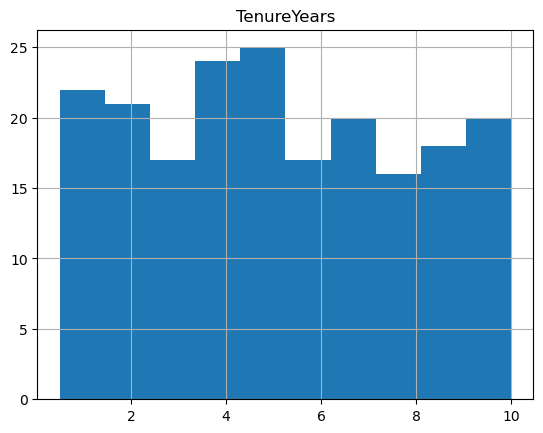

In [14]:
df.hist("TenureYears")

<Axes: xlabel='Age', ylabel='PurchaseFrequency'>

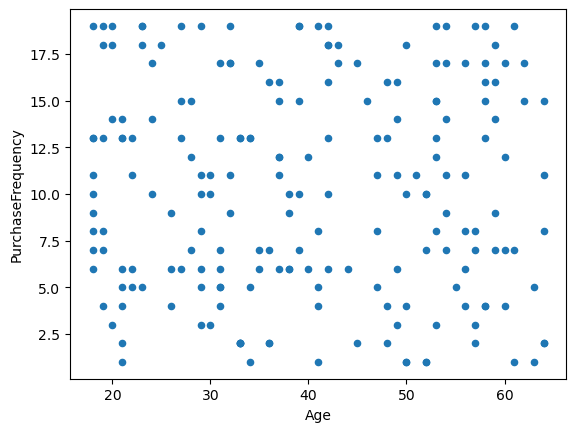

In [15]:
df.plot(kind="scatter",x="Age",y="PurchaseFrequency")

In [17]:
import matplotlib.pyplot as plt

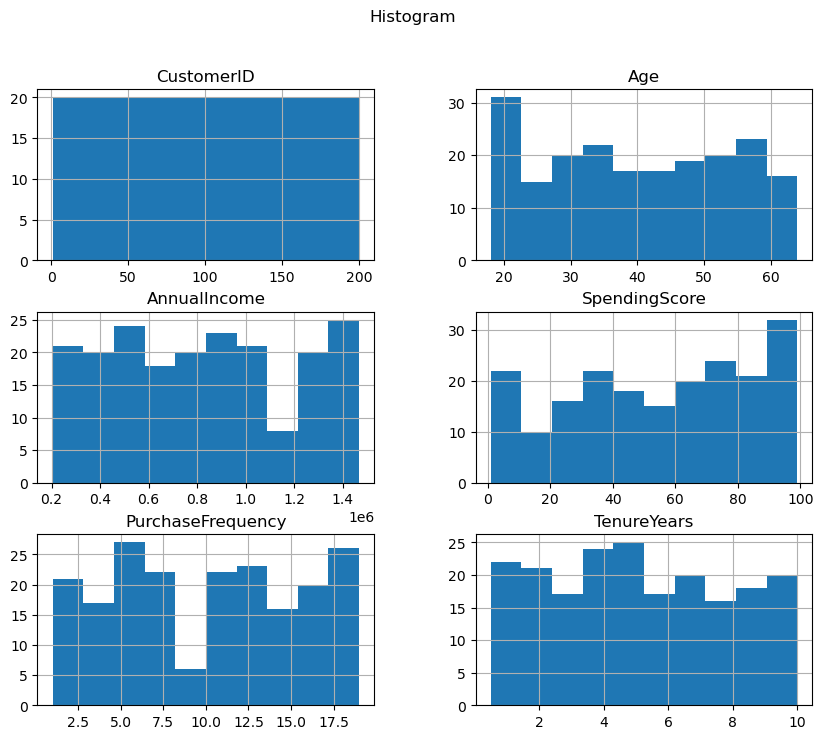

In [18]:
df.hist(figsize=(10,8))
plt.suptitle("Histogram")
plt.show()

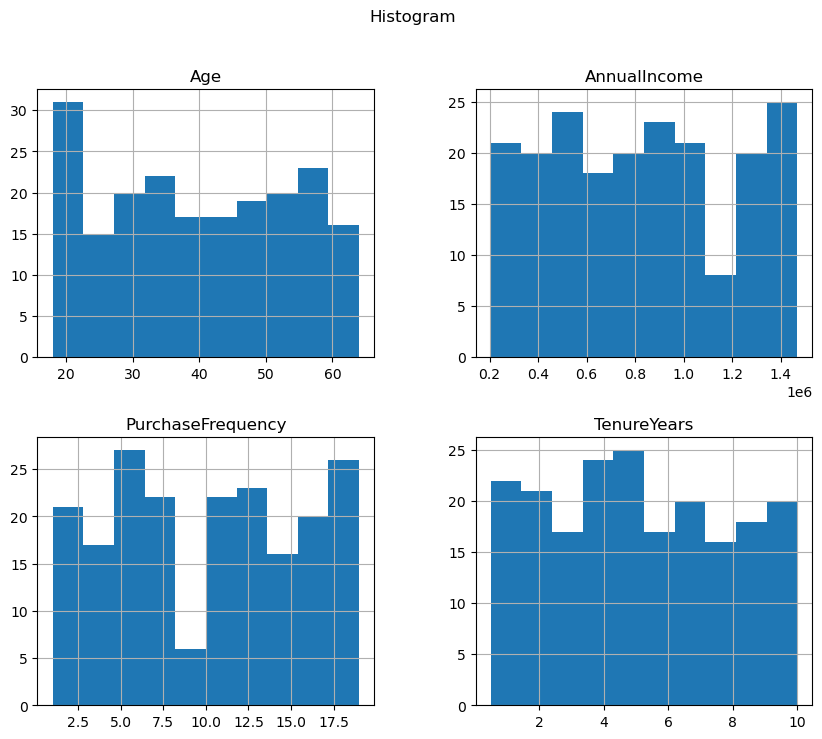

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
num_cols=['Age','AnnualIncome','PurchaseFrequency','TenureYears']

df[num_cols].hist(figsize=(10,8))
plt.suptitle("Histogram")
plt.show()

In [25]:
pivot_table=pd.pivot_table(df,values='SpendingScore',index='Gender',columns='CustomerSegment',aggfunc='mean')

pivot_table

CustomerSegment,High-Value,Low-Value,Mid-Value
Gender,,,
Female,50.857143,63.147059,54.705882
Male,56.827586,47.400000,54.394737


In [26]:
df.to_csv("customer_data.csv",index=False)

In [27]:
df.to_json("customer_data.json",index=False)

In [30]:
x=df.drop(['CustomerID','CustomerSegment','Gender','Age','SpendingScore'],axis=1)
y=df['CustomerSegment']
x_train, x_test, y_train, y_test=train_test_split(
    x,y,test_size=0.2
)